In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_path = "/content/drive/MyDrive/Frames of 5/open_video_mp_1_landmarks.csv"

df = pd.read_csv(csv_path)

print(df.shape)

df.head()

(264, 133)


,frame,x_0,y_0,z_0,visibility_0,x_1,y_1,z_1,visibility_1,x_2,...,z_30,visibility_30,x_31,y_31,z_31,visibility_31,x_32,y_32,z_32,visibility_32
0,frame_10.jpg,980.416548,516.326590,-0.068026,0.997587,985.920129,509.507530,-0.075936,0.997669,987.304866,...,0.129085,0.802828,1024.550891,768.949690,-0.038525,0.983684,1025.706496,767.721944,0.113552,0.835925
1,frame_100.jpg,978.479125,466.697316,0.078295,0.997814,976.087539,461.677179,0.067293,0.997876,974.559376,...,0.009538,0.821449,968.376498,720.038066,-0.051731,0.983237,986.605680,713.439331,-0.010558,0.847015
2,frame_101.jpg,965.914993,460.840333,0.127731,0.998007,965.111544,456.794336,0.116998,0.998056,964.386728,...,0.018232,0.836052,965.473235,716.512499,-0.068624,0.980444,982.560139,708.844056,-0.001159,0.841483
3,frame_102.jpg,1017.913644,529.775567,-0.156989,0.998098,1023.116226,522.459655,-0.151782,0.998113,1023.623700,...,0.007783,0.818516,1031.118834,687.568440,-0.060997,0.954188,1002.747657,681.279016,-0.023759,0.828718
4,frame_103.jpg,971.642170,529.683566,-0.155095,0.998267,972.415376,525.125244,-0.046342,0.998280,973.306787,...,-0.021312,0.782038,1029.840000,671.397462,-0.046474,0.921764,1002.007360,683.283682,-0.041874,0.805412


In [ ]:
# LEFT HIP
left_hip_x = df["x_23"]
left_hip_y = df["y_23"]

# RIGHT HIP
right_hip_x = df["x_24"]
right_hip_y = df["y_24"]

# HIP CENTER
df["hip_center_x"] = (left_hip_x + right_hip_x) / 2

df["hip_center_y"] = (left_hip_y + right_hip_y) / 2

print("Hip center extracted successfully 🔥")

Hip center extracted successfully 🔥


In [ ]:
df[[
    "frame",
    "hip_center_x",
    "hip_center_y"
]].head()

,frame,hip_center_x,hip_center_y
0,frame_10.jpg,1016.994245,635.799935
1,frame_100.jpg,977.325827,579.823775
2,frame_101.jpg,975.936476,568.598504
3,frame_102.jpg,1005.058150,600.019140
4,frame_103.jpg,976.087744,614.836645


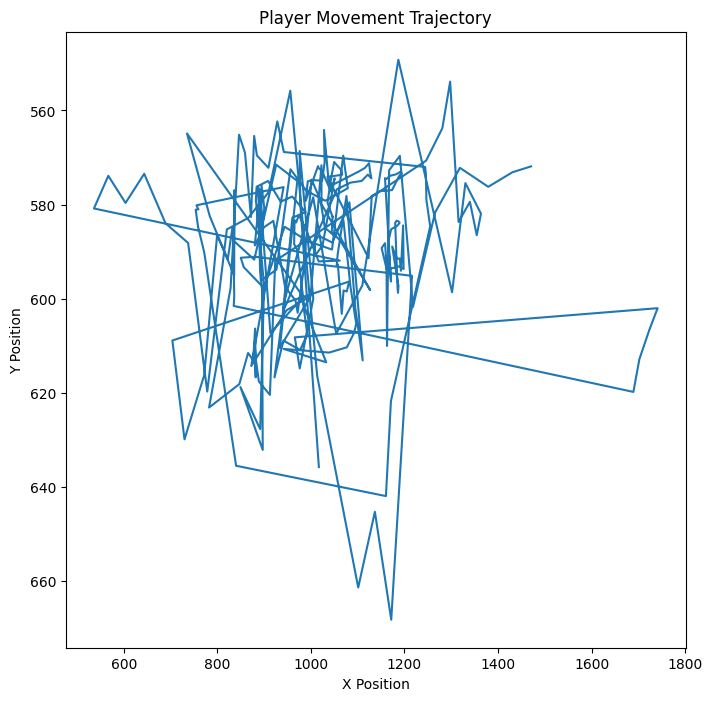

In [ ]:
plt.figure(figsize=(8,8))

plt.plot(
    df["hip_center_x"],
    df["hip_center_y"]
)

# Invert because image coordinates start from top-left
plt.gca().invert_yaxis()

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.title("Player Movement Trajectory")

plt.show()

In [ ]:
# Difference between consecutive frames

dx = df["hip_center_x"].diff()

dy = df["hip_center_y"].diff()

# Euclidean distance
df["speed"] = np.sqrt(dx**2 + dy**2)

# Fill first NaN value
df["speed"] = df["speed"].fillna(0)

df["speed_smoothed"] = (
    df["speed"]
    .rolling(window=3, center=True)
    .mean()
    .fillna(df["speed"])
)
print("Speed calculated successfully 🔥")


Speed calculated successfully 🔥


In [ ]:
df[[
    "frame",
    "hip_center_x",
    "hip_center_y",
    "speed"
]].head()

,frame,hip_center_x,hip_center_y,speed
0,frame_10.jpg,1016.994245,635.799935,0.000000
1,frame_100.jpg,977.325827,579.823775,68.606952
2,frame_101.jpg,975.936476,568.598504,11.310924
3,frame_102.jpg,1005.058150,600.019140,42.840732
4,frame_103.jpg,976.087744,614.836645,32.539866


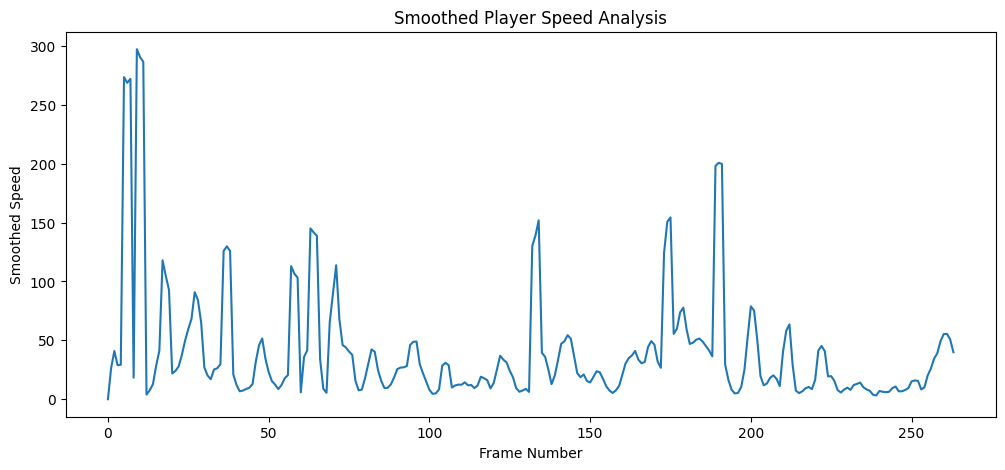

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["speed_smoothed"])

plt.xlabel("Frame Number")

plt.ylabel("Smoothed Speed")

plt.title("Smoothed Player Speed Analysis")

plt.show()

In [ ]:
df["dx"] = df["hip_center_x"].diff()

df["dy"] = df["hip_center_y"].diff()

df = df.fillna(0)

print("dx and dy calculated 🔥")

dx and dy calculated 🔥


In [ ]:
# =========================================
# CALCULATE FRAME-TO-FRAME MOVEMENT
# =========================================

df["dx"] = df["hip_center_x"].diff()

df["dy"] = df["hip_center_y"].diff()

# Fill first NaN row
df[["dx", "dy"]] = df[["dx", "dy"]].fillna(0)

print("dx and dy calculated 🔥")


# =========================================
# DIRECTION ANALYSIS
# =========================================

threshold = 0.005

# Create conditions
conditions = [

    # RIGHT MOVEMENT
    (df['dx'] > threshold),

    # LEFT MOVEMENT
    (df['dx'] < -threshold),

    # FORWARD / NET MOVEMENT
    # Y decreases in image coordinates
    (df['dy'] < -threshold),

    # BACKWARD / BASELINE MOVEMENT
    # Y increases in image coordinates
    (df['dy'] > threshold)
]

# Corresponding labels
choices = [
    'RIGHT',
    'LEFT',
    'FORWARD',
    'BACKWARD'
]

# Apply vectorized direction classification
df['direction'] = np.select(
    conditions,
    choices,
    default='STILL'
)

print("Direction analysis completed 🔥")


# =========================================
# CHECK OUTPUT
# =========================================

df[[
    "frame",
    "dx",
    "dy",
    "direction"
]].head(20)

dx and dy calculated 🔥
Direction analysis completed 🔥


,frame,dx,dy,direction
0,frame_10.jpg,0.000000,0.000000,STILL
1,frame_100.jpg,-39.668418,-55.976160,LEFT
2,frame_101.jpg,-1.389351,-11.225271,LEFT
3,frame_102.jpg,29.121674,31.420636,RIGHT
4,frame_103.jpg,-28.970406,14.817505,LEFT
5,frame_104.jpg,-10.484463,-6.610117,LEFT
6,frame_107.jpg,775.486417,-6.197319,RIGHT
7,frame_108.jpg,-17.467099,4.559948,LEFT
8,frame_109.jpg,-21.526122,6.296217,LEFT
9,frame_110.jpg,-12.741851,6.939437,LEFT


In [ ]:
df[[
    "frame",
    "dx",
    "dy",
    "direction"
]].head(20)

,frame,dx,dy,direction
0,frame_10.jpg,0.000000,0.000000,STILL
1,frame_100.jpg,-39.668418,-55.976160,FRONT
2,frame_101.jpg,-1.389351,-11.225271,FRONT
3,frame_102.jpg,29.121674,31.420636,BACK
4,frame_103.jpg,-28.970406,14.817505,BACK
5,frame_104.jpg,-10.484463,-6.610117,FRONT
6,frame_107.jpg,775.486417,-6.197319,FRONT
7,frame_108.jpg,-17.467099,4.559948,BACK
8,frame_109.jpg,-21.526122,6.296217,BACK
9,frame_110.jpg,-12.741851,6.939437,BACK


In [ ]:
# LEFT ANKLE
left_ankle_x = df["x_27"]
left_ankle_y = df["y_27"]

# RIGHT ANKLE
right_ankle_x = df["x_28"]
right_ankle_y = df["y_28"]

print("Ankle coordinates extracted 🔥")

Ankle coordinates extracted 🔥


In [ ]:
df["stance_width"] = np.sqrt(
    (right_ankle_x - left_ankle_x)**2 +
    (right_ankle_y - left_ankle_y)**2
)

print("Stance width calculated 🔥")

Stance width calculated 🔥


In [ ]:
df[[
    "frame",
    "stance_width"
]].head(20)

,frame,stance_width
0,frame_10.jpg,1.742708
1,frame_100.jpg,11.110867
2,frame_101.jpg,13.150222
3,frame_102.jpg,9.324316
4,frame_103.jpg,16.536898
5,frame_104.jpg,47.000127
6,frame_107.jpg,105.223467
7,frame_108.jpg,13.435940
8,frame_109.jpg,33.640311
9,frame_110.jpg,40.443114


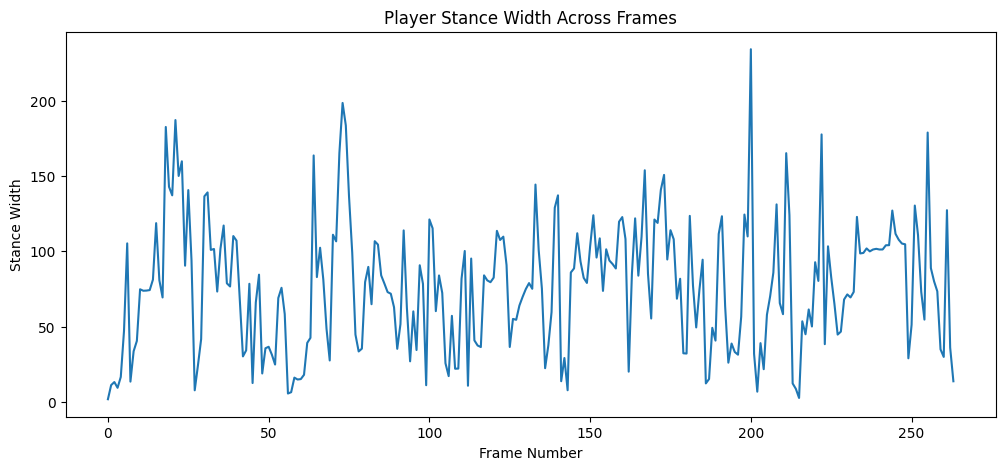

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["stance_width"])

plt.xlabel("Frame Number")

plt.ylabel("Stance Width")

plt.title("Player Stance Width Across Frames")

plt.show()

In [ ]:
# Average player position

center_x = df["hip_center_x"].mean()

center_y = df["hip_center_y"].mean()

print("Court Center X:", center_x)
print("Court Center Y:", center_y)

Court Center X: 1021.2399493846478
Court Center Y: 589.41016604503


In [ ]:
df["recovery_distance"] = np.sqrt(
    (df["hip_center_x"] - center_x)**2 +
    (df["hip_center_y"] - center_y)**2
)

print("Recovery distance calculated 🔥")

Recovery distance calculated 🔥


In [ ]:
df[[
    "frame",
    "recovery_distance"
]].head(20)

,frame,recovery_distance
0,frame_10.jpg,46.583652
1,frame_100.jpg,44.948293
2,frame_101.jpg,49.855090
3,frame_102.jpg,19.349443
4,frame_103.jpg,51.819181
5,frame_104.jpg,58.732396
6,frame_107.jpg,719.960347
7,frame_108.jpg,702.592701
8,frame_109.jpg,681.261107
9,frame_110.jpg,668.806603


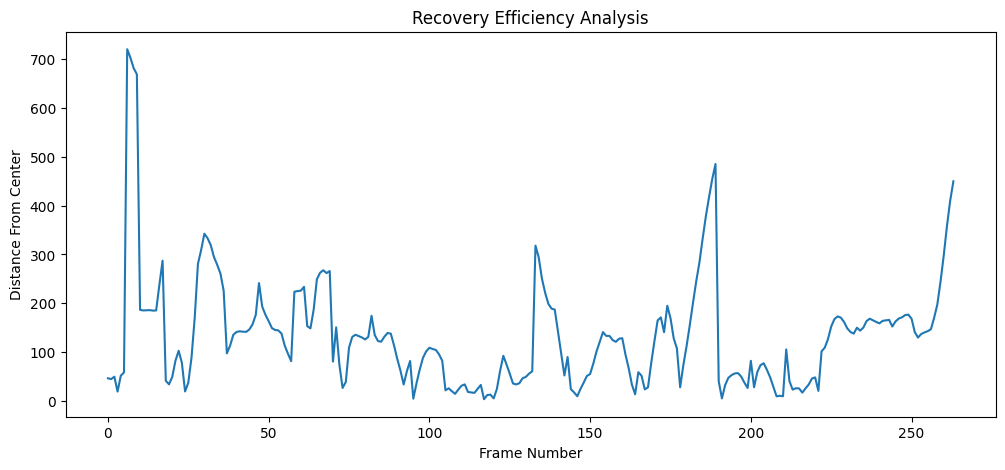

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["recovery_distance"])

plt.xlabel("Frame Number")

plt.ylabel("Distance From Center")

plt.title("Recovery Efficiency Analysis")

plt.show()

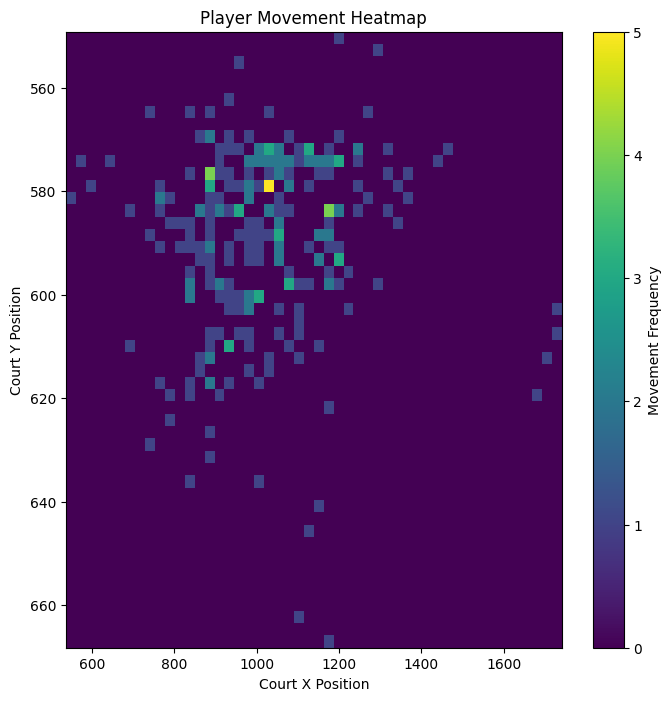

In [ ]:
plt.figure(figsize=(8,8))

plt.hist2d(
    df["hip_center_x"],
    df["hip_center_y"],
    bins=50
)

plt.gca().invert_yaxis()

plt.colorbar(label="Movement Frequency")

plt.xlabel("Court X Position")

plt.ylabel("Court Y Position")

plt.title("Player Movement Heatmap")

plt.show()

In [ ]:
feature_csv_path = "/content/drive/MyDrive/Frames of 5/movement_features_video1.csv"

df.to_csv(feature_csv_path, index=False)

print("Feature CSV Saved Successfully 🔥")

Feature CSV Saved Successfully 🔥


In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
# =========================================
# MAIN FOLDER
# =========================================

main_folder = "/content/drive/MyDrive/Frames of 5"

# =========================================
# GET ALL LANDMARK CSV FILES
# =========================================

csv_files = [
    file for file in os.listdir(main_folder)
    if file.endswith("_landmarks.csv")
]

print("Landmark CSV Files Found:")
print(csv_files)

# =========================================
# PROCESS EACH CSV
# =========================================

for csv_file in csv_files:

    print(f"\nProcessing {csv_file} 🔥")

    # Full path
    csv_path = os.path.join(main_folder, csv_file)

    # Load CSV
    df = pd.read_csv(csv_path)

    # =========================================
    # HIP CENTER
    # =========================================

    df["hip_center_x"] = (
        df["x_23"] + df["x_24"]
    ) / 2

    df["hip_center_y"] = (
        df["y_23"] + df["y_24"]
    ) / 2

    # =========================================
    # SPEED
    # =========================================

    dx = df["hip_center_x"].diff()

    dy = df["hip_center_y"].diff()

    df["speed"] = np.sqrt(dx**2 + dy**2)

    df["speed"] = df["speed"].fillna(0)

    # =========================================
    # SPEED SMOOTHING
    # =========================================

    df["speed_smoothed"] = (
        df["speed"]
        .rolling(window=3, center=True)
        .mean()
        .fillna(df["speed"])
    )

    # =========================================
    # DIRECTION ANALYSIS
    # =========================================

    df["dx"] = dx.fillna(0)

    df["dy"] = dy.fillna(0)

    threshold = 0.005

    conditions = [

        # RIGHT
        (df["dx"] > threshold),

        # LEFT
        (df["dx"] < -threshold),

        # FORWARD
        (df["dy"] < -threshold),

        # BACKWARD
        (df["dy"] > threshold)
    ]

    choices = [
        "RIGHT",
        "LEFT",
        "FORWARD",
        "BACKWARD"
    ]

    df["direction"] = np.select(
        conditions,
        choices,
        default="STILL"
    )

    # =========================================
    # STANCE WIDTH
    # =========================================

    df["stance_width"] = np.sqrt(
        (df["x_28"] - df["x_27"])**2 +
        (df["y_28"] - df["y_27"])**2
    )

    # =========================================
    # RECOVERY DISTANCE
    # =========================================

    center_x = df["hip_center_x"].mean()

    center_y = df["hip_center_y"].mean()

    df["recovery_distance"] = np.sqrt(
        (df["hip_center_x"] - center_x)**2 +
        (df["hip_center_y"] - center_y)**2
    )

    # =========================================
    # SAVE FEATURE CSV
    # =========================================

    feature_file_name = csv_file.replace(
        "_landmarks.csv",
        "_features.csv"
    )

    feature_csv_path = os.path.join(
        main_folder,
        feature_file_name
    )

    df.to_csv(feature_csv_path, index=False)

    print(f"{feature_file_name} saved successfully ✅")

print("\nALL FEATURE CSV FILES CREATED SUCCESSFULLY 🔥")

Landmark CSV Files Found:
['open_video_mp_1_landmarks.csv', 'open_video_trim_2_landmarks.csv', 'open_video_trim_3_landmarks.csv', 'Badminton full court_landmarks.csv']

Processing open_video_mp_1_landmarks.csv 🔥
open_video_mp_1_features.csv saved successfully ✅

Processing open_video_trim_2_landmarks.csv 🔥
open_video_trim_2_features.csv saved successfully ✅

Processing open_video_trim_3_landmarks.csv 🔥
open_video_trim_3_features.csv saved successfully ✅

Processing Badminton full court_landmarks.csv 🔥
Badminton full court_features.csv saved successfully ✅

ALL FEATURE CSV FILES CREATED SUCCESSFULLY 🔥


In [ ]:
# =========================================
# IMPORTS
# =========================================

import pandas as pd
import numpy as np
import os
import re

from google.colab import drive
from google.colab import files

# =========================================
# MOUNT DRIVE
# =========================================

drive.mount('/content/drive')

# =========================================
# MAIN FOLDER
# =========================================

main_folder = "/content/drive/MyDrive/Frames of 5"

# =========================================
# LIST OF FEATURE CSV FILES
# =========================================

feature_files = {
    "open_video_trim_3_features.csv": "trim_3",
    "open_video_trim_2_features.csv": "trim_2",
    "open_video_mp_1_features.csv": "trim_1",
    "Badminton full court_features.csv": "full_court",
}

# =========================================
# RENAME LANDMARK COLUMNS
# =========================================

column_rename_map = {

    'x_11': 'left_shoulder_x',
    'y_11': 'left_shoulder_y',

    'x_12': 'right_shoulder_x',
    'y_12': 'right_shoulder_y',

    'x_23': 'left_hip_x',
    'y_23': 'left_hip_y',

    'x_24': 'right_hip_x',
    'y_24': 'right_hip_y',

    'x_25': 'left_knee_x',
    'y_25': 'left_knee_y',

    'x_26': 'right_knee_x',
    'y_26': 'right_knee_y',

    'x_27': 'left_ankle_x',
    'y_27': 'left_ankle_y',

    'x_28': 'right_ankle_x',
    'y_28': 'right_ankle_y',

    'x_31': 'left_foot_x',
    'y_31': 'left_foot_y',

    'x_32': 'right_foot_x',
    'y_32': 'right_foot_y'
}

# =========================================
# STORE ALL DATAFRAMES
# =========================================

processed_dfs = []

print("🔄 Processing feature files...")

# =========================================
# LOOP THROUGH CSV FILES
# =========================================

for filename, short_name in feature_files.items():

    # Full CSV path
    file_path = os.path.join(main_folder, filename)

    # Check existence
    if not os.path.exists(file_path):

        print(f"❌ File NOT found: {filename}")

        continue

    print(f"✅ Processing: {filename}")

    # Load CSV
    df = pd.read_csv(file_path)

    # =========================================
    # RENAME COLUMNS
    # =========================================

    df = df.rename(columns=column_rename_map)

    # =========================================
    # KEEP IMPORTANT COLUMNS
    # =========================================

    keep_cols = ['frame'] + list(column_rename_map.values())

    available_cols = [
        c for c in keep_cols
        if c in df.columns
    ]

    df = df[available_cols]

    # =========================================
    # SOURCE VIDEO COLUMN
    # =========================================

    df['source_video'] = filename.replace(
        '_features.csv',
        ''
    )

    # =========================================
    # CLEAN FRAME NAMES
    # =========================================

    def format_frame_string(row):

        val = str(row['frame'])

        nums = re.findall(r'\d+', val)

        idx = int(nums[-1]) if nums else 0

        return f"frame_{idx}_{short_name}.jpg"

    df['frame'] = df.apply(
        format_frame_string,
        axis=1
    )

    # =========================================
    # APPEND DATAFRAME
    # =========================================

    processed_dfs.append(df)

# =========================================
# CHECK IF FILES LOADED
# =========================================

if len(processed_dfs) == 0:

    print("❌ No CSV files were loaded.")

else:

    # =========================================
    # MERGE ALL DATAFRAMES
    # =========================================

    master_features_df = pd.concat(
        processed_dfs,
        ignore_index=True
    )

    print(f"\n📊 Total Rows: {len(master_features_df)}")

    # =========================================
    # COMPUTE HIP CENTER
    # =========================================

    master_features_df['hip_center_x'] = (
        master_features_df['left_hip_x'] +
        master_features_df['right_hip_x']
    ) / 2

    master_features_df['hip_center_y'] = (
        master_features_df['left_hip_y'] +
        master_features_df['right_hip_y']
    ) / 2

    # =========================================
    # STANCE WIDTH
    # =========================================

    master_features_df['stance_width'] = abs(
        master_features_df['left_ankle_x'] -
        master_features_df['right_ankle_x']
    )

    # =========================================
    # COURT BOUNDARIES
    # =========================================

    mid_court_x = master_features_df[
        'hip_center_x'
    ].median()

    back_court_boundary = master_features_df[
        'hip_center_y'
    ].quantile(0.33)

    front_court_boundary = master_features_df[
        'hip_center_y'
    ].quantile(0.66)

    lunge_threshold = master_features_df[
        'stance_width'
    ].quantile(0.60)

    print("\n📍 Court Boundaries Calculated")

    # =========================================
    # LABELING ENGINE
    # =========================================

    def labeling_engine(row):

        x = row['hip_center_x']
        y = row['hip_center_y']
        w = row['stance_width']

        # Side
        side = (
            "Forehand"
            if x >= mid_court_x
            else "Backhand"
        )

        # Court depth
        if y <= back_court_boundary:

            depth = "Backcourt"

        elif y >= front_court_boundary:

            depth = "Front"

        else:

            depth = "Mid"

        # Recovery detection
        if (
            w < lunge_threshold
            and
            abs(x - mid_court_x) < 0.05
        ):

            return "Recovery_Ready"

        return f"{side}_{depth}"

    # =========================================
    # APPLY LABELS
    # =========================================

    print("🧠 Applying labels...")

    master_features_df[
        'footwork_label'
    ] = master_features_df.apply(
        labeling_engine,
        axis=1
    )

    # =========================================
    # LABEL DISTRIBUTION
    # =========================================

    print("\n📋 Label Distribution:\n")

    print(
        master_features_df[
            'footwork_label'
        ].value_counts()
    )

    # =========================================
    # SAVE FINAL DATASET
    # =========================================

    final_output = os.path.join(
        main_folder,
        "standardized_perfect_dataset.csv"
    )

    master_features_df.to_csv(
        final_output,
        index=False
    )

    print(f"\n🚀 Final dataset saved:")
    print(final_output)

    # =========================================
    # DOWNLOAD
    # =========================================

    files.download(final_output)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Processing feature files...
✅ Processing: open_video_trim_3_features.csv
✅ Processing: open_video_trim_2_features.csv
✅ Processing: open_video_mp_1_features.csv
✅ Processing: Badminton full court_features.csv

📊 Total Rows: 1260

📍 Court Boundaries Calculated
🧠 Applying labels...

📋 Label Distribution:

footwork_label
Forehand_Front        281
Backhand_Mid          209
Backhand_Backcourt    181
Recovery_Ready        174
Backhand_Front        146
Forehand_Backcourt    142
Forehand_Mid          127
Name: count, dtype: int64

🚀 Final dataset saved:
/content/drive/MyDrive/Frames of 5/standardized_perfect_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================
# IMPORTS
# =========================================

import pandas as pd
import numpy as np

from google.colab import drive
from google.colab import files

# =========================================
# MOUNT DRIVE
# =========================================

drive.mount('/content/drive')

# =========================================
# LOAD FINAL DATASET
# =========================================

dataset_path = "/content/drive/MyDrive/Frames of 5/standardized_perfect_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully 🔥")
print(df.shape)

# =========================================
# SORT BY SOURCE VIDEO + FRAME
# IMPORTANT FOR MOTION FEATURES
# =========================================

df = df.sort_values(
    by=["source_video", "frame"]
).reset_index(drop=True)

# =========================================
# DX / DY CALCULATION
# =========================================

df["dx"] = df.groupby("source_video")[
    "hip_center_x"
].diff()

df["dy"] = df.groupby("source_video")[
    "hip_center_y"
].diff()

# Fill NaN
df["dx"] = df["dx"].fillna(0)

df["dy"] = df["dy"].fillna(0)

print("dx/dy calculated ✅")

# =========================================
# SPEED
# =========================================

df["speed"] = np.sqrt(
    df["dx"]**2 +
    df["dy"]**2
)

print("Speed calculated ✅")

# =========================================
# SPEED SMOOTHING
# =========================================

df["speed_smoothed"] = (
    df.groupby("source_video")["speed"]
    .transform(
        lambda x:
        x.rolling(
            window=3,
            center=True
        ).mean()
    )
)

# Fill missing values
df["speed_smoothed"] = df[
    "speed_smoothed"
].fillna(df["speed"])

print("Smoothed speed calculated ✅")

# =========================================
# RECOVERY DISTANCE
# =========================================

# Per-video center position
video_center_x = df.groupby(
    "source_video"
)["hip_center_x"].transform("mean")

video_center_y = df.groupby(
    "source_video"
)["hip_center_y"].transform("mean")

df["recovery_distance"] = np.sqrt(
    (df["hip_center_x"] - video_center_x)**2 +
    (df["hip_center_y"] - video_center_y)**2
)

print("Recovery distance calculated ✅")

# =========================================
# DIRECTION LABELS
# =========================================

threshold = 0.005

conditions = [

    (df["dx"] > threshold),

    (df["dx"] < -threshold),

    (df["dy"] < -threshold),

    (df["dy"] > threshold)
]

choices = [
    "RIGHT",
    "LEFT",
    "FORWARD",
    "BACKWARD"
]

df["direction"] = np.select(
    conditions,
    choices,
    default="STILL"
)

print("Direction labels added ✅")

# =========================================
# CHECK FINAL FEATURES
# =========================================

print("\nFINAL FEATURE COLUMNS:\n")

important_cols = [

    "frame",
    "source_video",

    "hip_center_x",
    "hip_center_y",

    "dx",
    "dy",

    "speed",
    "speed_smoothed",

    "stance_width",

    "recovery_distance",

    "direction",

    "footwork_label"
]

print(df[important_cols].head())

# =========================================
# SAVE UPDATED DATASET
# =========================================

output_path = "/content/drive/MyDrive/Frames of 5/final_rf_ready_dataset.csv"

df.to_csv(output_path, index=False)

print("\n🔥 FINAL RF-READY DATASET SAVED 🔥")

print(output_path)

# =========================================
# DOWNLOAD
# =========================================

files.download(output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully 🔥
(1260, 26)
dx/dy calculated ✅
Speed calculated ✅
Smoothed speed calculated ✅
Recovery distance calculated ✅
Direction labels added ✅

FINAL FEATURE COLUMNS:

                      frame          source_video  hip_center_x  hip_center_y  \
0    frame_0_full_court.jpg  Badminton full court      0.460660      0.536042   
1  frame_100_full_court.jpg  Badminton full court      0.460108      0.532402   
2  frame_101_full_court.jpg  Badminton full court      0.463585      0.531658   
3  frame_102_full_court.jpg  Badminton full court      0.478598      0.533024   
4  frame_103_full_court.jpg  Badminton full court      0.495374      0.533916   

         dx        dy     speed  speed_smoothed  stance_width  \
0  0.000000  0.000000  0.000000        0.000000      0.057718   
1 -0.000552 -0.003640  0.003682        0.002412      0.062541   
2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================
# IMPORTS
# =========================================

import pandas as pd

from google.colab import drive

# =========================================
# MOUNT DRIVE
# =========================================

drive.mount('/content/drive')

# =========================================
# LOAD FINAL RF DATASET
# =========================================

dataset_path = "/content/drive/MyDrive/Frames of 5/final_rf_ready_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully 🔥")

print(df.shape)

# View columns
print("\nColumns:\n")

print(df.columns.tolist())

In [ ]:
import json

with open("/mnt/data/Movement analysis and trajectory.ipynb", "r") as f:
    nb = json.load(f)

for cell in nb["cells"]:
    if cell["cell_type"] == "code":
        src = "".join(cell["source"])
        if any(x in src for x in [
            "dx", "dy", "speed",
            "speed_smoothed",
            "recovery_distance"
        ]):
            print("=" * 80)
            print(src)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Movement analysis and trajectory.ipynb'